# 4. Pembangunan dan Pelatihan Model (Transfer Learning ResNet-50)
Tahapan pada notebook ini:
1. Menyiapkan Data Generator (dengan augmentasi aman untuk citra medis).
2. Membangun arsitektur Transfer Learning ResNet-50 dengan tambahan *Batch Normalization* agar komputasi stabil.
3. Melatih model menggunakan *Callbacks* (`ModelCheckpoint` & `EarlyStopping`).
4. Memvisualisasikan dan menyimpan grafik akurasi/loss (*Learning Curve*).

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
import os

# 1. Menyiapkan Data Generator
train_datagen = ImageDataGenerator(
    rescale=1./255, 
    rotation_range=15, 
    zoom_range=0.15,
    width_shift_range=0.1, 
    height_shift_range=0.1, 
    fill_mode='nearest'
    # horizontal_flip=False (secara default sudah False, sangat aman untuk X-Ray)
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '../dataset/processed/train', 
    target_size=(224, 224), 
    batch_size=32, 
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    '../dataset/processed/val', 
    target_size=(224, 224), 
    batch_size=32, 
    class_mode='categorical'
)

# Menampilkan Class Indices (Sangat krusial untuk evaluasi/Confusion Matrix nanti)
print("\nMapping Kelas ke Indeks Angka:")
print(train_generator.class_indices)

Found 10606 images belonging to 3 classes.
Found 2271 images belonging to 3 classes.

Mapping Kelas ke Indeks Angka:
{'COVID': 0, 'Normal': 1, 'Viral_Pneumonia': 2}


In [2]:
# 2. Memuat Model Dasar ResNet-50
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Membekukan (freeze) otak dasar agar bobot pre-trained tidak rusak
for layer in base_model.layers:
    layer.trainable = False

# 3. Menambahkan Custom Head (Spesialisasi dengan Batch Normalization)
x = base_model.output
x = GlobalAveragePooling2D()(x)

# Menormalkan sinyal dari ResNet sebelum masuk ke lapisan Dense kita
x = BatchNormalization()(x) 
x = Dense(512, activation='relu')(x)

# Menormalkan kembali sebelum masuk ke Dropout
x = BatchNormalization()(x) 
x = Dropout(0.5)(x)

# Output layer: 3 neuron karena ada 3 kelas (COVID, Normal, Viral_Pneumonia)
predictions = Dense(3, activation='softmax')(x)

# Menggabungkan otak dasar dan lapisan baru menjadi model final
model = Model(inputs=base_model.input, outputs=predictions)

print("Arsitektur Model ResNet-50 (Optimized with BatchNorm) Berhasil Dibangun!")

Arsitektur Model ResNet-50 (Optimized with BatchNorm) Berhasil Dibangun!


In [3]:
# 4. Kompilasi Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

# 5. Menyiapkan Callbacks (Asisten Pelatihan)
# Menyimpan model terbaik secara otomatis ke folder 'models'
checkpoint = ModelCheckpoint(
    '../models/resnet50_best_model.h5', 
    monitor='val_accuracy', 
    save_best_only=True, 
    mode='max', 
    verbose=1
)

# Menghentikan pelatihan jika selama 5 putaran tidak ada peningkatan val_loss
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

print("Model dikompilasi dan siap dilatih!")

Model dikompilasi dan siap dilatih!


In [4]:
# 6. EKSEKUSI TRAINING
EPOCHS = 20 # Maksimal putaran belajar, bisa berhenti lebih cepat berkat EarlyStopping

print("Training model ResNet50 sedang berjalan...")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[checkpoint, early_stop]
)
print("Training Selesai!")

Training model ResNet50 sedang berjalan...
Epoch 1/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4643 - loss: 1.3830
Epoch 1: val_accuracy improved from None to 0.67327, saving model to ../models/resnet50_best_model.h5



Epoch 1: finished saving model to ../models/resnet50_best_model.h5
332/332 ━━━━━━━━━━━━━━━━━━━━ 613s 2s/step - accuracy: 0.5256 - loss: 1.2287 - val_accuracy: 0.6733 - val_loss: 0.7411
Epoch 2/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6304 - loss: 0.9517
Epoch 2: val_accuracy improved from 0.67327 to 0.86658, saving model to ../models/resnet50_best_model.h5



Epoch 2: finished saving model to ../models/resnet50_best_model.h5
332/332 ━━━━━━━━━━━━━━━━━━━━ 621s 2s/step - accuracy: 0.6517 - loss: 0.8986 - val_accuracy: 0.8666 - val_loss: 0.4477
Epoch 3/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7028 - loss: 0.7740
Epoch 3: val_accuracy improved from 0.86658 to 0.86790, saving model to ../models/resnet50_best_model.h5



Epoch 3: finished saving model to ../models/resnet50_best_model.h5
332/332 ━━━━━━━━━━━━━━━━━━━━ 596s 2s/step - accuracy: 0.7112 - loss: 0.7448 - val_accuracy: 0.8679 - val_loss: 0.3914
Epoch 4/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7242 - loss: 0.6996
Epoch 4: val_accuracy did not improve from 0.86790
332/332 ━━━━━━━━━━━━━━━━━━━━ 625s 2s/step - accuracy: 0.7357 - loss: 0.6837 - val_accuracy: 0.8617 - val_loss: 0.3691
Epoch 5/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7521 - loss: 0.6339
Epoch 5: val_accuracy improved from 0.86790 to 0.86878, saving model to ../models/resnet50_best_model.h5



Epoch 5: finished saving model to ../models/resnet50_best_model.h5
332/332 ━━━━━━━━━━━━━━━━━━━━ 648s 2s/step - accuracy: 0.7531 - loss: 0.6256 - val_accuracy: 0.8688 - val_loss: 0.3767
Epoch 6/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7526 - loss: 0.6089
Epoch 6: val_accuracy improved from 0.86878 to 0.87186, saving model to ../models/resnet50_best_model.h5


...


Epoch 7: finished saving model to ../models/resnet50_best_model.h5
332/332 ━━━━━━━━━━━━━━━━━━━━ 624s 2s/step - accuracy: 0.7752 - loss: 0.5723 - val_accuracy: 0.8793 - val_loss: 0.3293
Epoch 8/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7839 - loss: 0.5387
Epoch 8: val_accuracy did not improve from 0.87935
332/332 ━━━━━━━━━━━━━━━━━━━━ 624s 2s/step - accuracy: 0.7869 - loss: 0.5393 - val_accuracy: 0.8697 - val_loss: 0.3372
Epoch 9/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7808 - loss: 0.5444
Epoch 9: val_accuracy improved from 0.87935 to 0.88771, saving model to ../models/resnet50_best_model.h5



Epoch 9: finished saving model to ../models/resnet50_best_model.h5
332/332 ━━━━━━━━━━━━━━━━━━━━ 622s 2s/step - accuracy: 0.7882 - loss: 0.5270 - val_accuracy: 0.8877 - val_loss: 0.3155
Epoch 10/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7901 - loss: 0.5144
Epoch 10: val_accuracy did not improve from 0.88771
332/332 ━━━━━━━━━━━━━━━━━━━━ 614s 2s/step - accuracy: 0.7912 - loss: 0.5075 - val_accuracy: 0.8635 - val_loss: 0.3491
Epoch 11/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7997 - loss: 0.5033
Epoch 11: val_accuracy improved from 0.88771 to 0.88904, saving model to ../models/resnet50_best_model.h5



Epoch 11: finished saving model to ../models/resnet50_best_model.h5
332/332 ━━━━━━━━━━━━━━━━━━━━ 619s 2s/step - accuracy: 0.7995 - loss: 0.5017 - val_accuracy: 0.8890 - val_loss: 0.3116
Epoch 12/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8070 - loss: 0.4897
Epoch 12: val_accuracy did not improve from 0.88904
332/332 ━━━━━━━━━━━━━━━━━━━━ 634s 2s/step - accuracy: 0.8060 - loss: 0.4904 - val_accuracy: 0.8886 - val_loss: 0.3037
Epoch 13/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8004 - loss: 0.4887
Epoch 13: val_accuracy improved from 0.88904 to 0.89564, saving model to ../models/resnet50_best_model.h5



Epoch 13: finished saving model to ../models/resnet50_best_model.h5
332/332 ━━━━━━━━━━━━━━━━━━━━ 590s 2s/step - accuracy: 0.8061 - loss: 0.4805 - val_accuracy: 0.8956 - val_loss: 0.2911
Epoch 14/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8072 - loss: 0.4612
Epoch 14: val_accuracy improved from 0.89564 to 0.90181, saving model to ../models/resnet50_best_model.h5



Epoch 14: finished saving model to ../models/resnet50_best_model.h5
332/332 ━━━━━━━━━━━━━━━━━━━━ 526s 2s/step - accuracy: 0.8109 - loss: 0.4673 - val_accuracy: 0.9018 - val_loss: 0.2860
Epoch 15/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8126 - loss: 0.4481
Epoch 15: val_accuracy did not improve from 0.90181
332/332 ━━━━━━━━━━━━━━━━━━━━ 526s 2s/step - accuracy: 0.8122 - loss: 0.4565 - val_accuracy: 0.8908 - val_loss: 0.3012
Epoch 16/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8200 - loss: 0.4429
Epoch 16: val_accuracy did not improve from 0.90181
332/332 ━━━━━━━━━━━━━━━━━━━━ 525s 2s/step - accuracy: 0.8140 - loss: 0.4538 - val_accuracy: 0.8895 - val_loss: 0.2881
Epoch 17/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8192 - loss: 0.4494
Epoch 17: val_accuracy did not improve from 0.90181
332/332 ━━━━━━━━━━━━━━━━━━━━ 521s 2s/step - accuracy: 0.8193 - loss: 0.4414 - val_accuracy: 0.8930 - val_loss: 0.2856
Epoch 18/20
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 1

Grafik berhasil disimpan ke folder 'results/training_accuracy_loss.png'


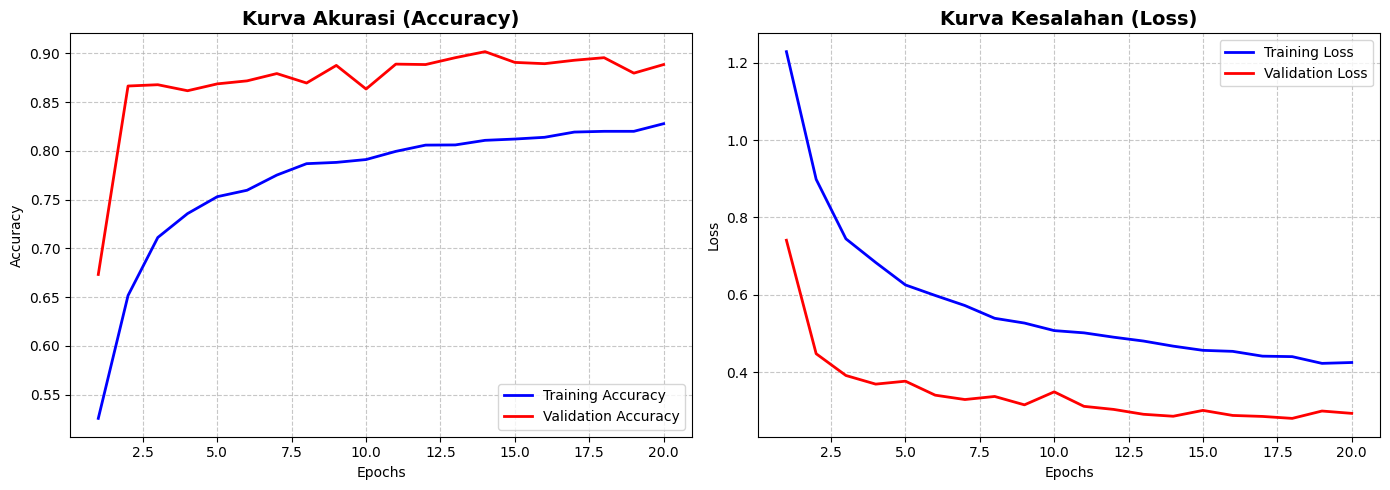

In [5]:
# 7. Memvisualisasikan dan Menyimpan Grafik Akurasi & Loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'b-', label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_acc, 'r-', label='Validation Accuracy', linewidth=2)
plt.title('Kurva Akurasi (Accuracy)', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(linestyle='--', alpha=0.7)

# Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'b-', label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, 'r-', label='Validation Loss', linewidth=2)
plt.title('Kurva Kesalahan (Loss)', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(linestyle='--', alpha=0.7)

plt.tight_layout()

# Menyimpan grafik ke folder results
plt.savefig('../results/training_accuracy_loss.png', dpi=300)
print("Grafik berhasil disimpan ke folder 'results/training_accuracy_loss.png'")
plt.show()